## Prediksi Biaya Asuransi — UTS Soft Computing
**Metode:** FIS Manual (Sugeno) → FIS Tuning GA → ANN NeuroFuzzy (PyTorch)  
**Dataset:** Kaggle mirichoi0218/insurance (1338 sampel) | Usia, BMI, Perokok → Biaya (Charges)  
**Pembagian Data:** 70% Train / 15% Validasi / 15% Test (stratifikasi berdasarkan kuartil BMI)

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Imports
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

print('✅ All imports successful')
print(f'   NumPy {np.__version__} | Pandas {pd.__version__} | PyTorch {torch.__version__}')

✅ All imports successful
   NumPy 2.2.6 | Pandas 2.3.3 | PyTorch 2.9.0+cpu


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Configuration / Hyperparameters
# ─────────────────────────────────────────────────────────────────────────────
RANDOM_SEED   = 42
TRAIN_RATIO   = 0.70
VAL_RATIO     = 0.15
TEST_RATIO    = 0.15

# FIS manual params
MF_CENTERS    = [0.2, 0.5, 0.8]   # low / medium / high
MF_SIGMAS     = 0.15
N_AGE_MF      = 3
N_BMI_MF      = 3
N_SMOKER_MF   = 2
N_RULES       = N_AGE_MF * N_BMI_MF * N_SMOKER_MF   # 18

# GA hyperparameters
GA_POP_SIZE   = 40
GA_GENS       = 50
GA_ETA_C      = 18    # SBX crowding distance
GA_ETA_M      = 20    # Polynomial mutation
GA_ELITISM    = 2
GA_CXPB       = 0.9
GA_MUTPB      = 0.1

# ANN hyperparameters
ANN_LR        = 0.01
ANN_EPOCHS    = 100
ANN_BATCH     = 32
ANN_PATIENCE  = 15

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print('✅ Config set — RANDOM_SEED =', RANDOM_SEED)
print(f'   GA: pop={GA_POP_SIZE}, gens={GA_GENS} | ANN: lr={ANN_LR}, epochs={ANN_EPOCHS}')

✅ Config set — RANDOM_SEED = 42
   GA: pop=40, gens=50 | ANN: lr=0.01, epochs=100


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Data Loading & Preprocessing
# ─────────────────────────────────────────────────────────────────────────────
import os

CSV_PATH = 'insurance.csv'
if not os.path.exists(CSV_PATH):
    # Generate synthetic dataset matching Kaggle mirichoi0218/insurance
    print('⚠️  insurance.csv not found — generating synthetic dataset...')
    rng = np.random.default_rng(RANDOM_SEED)
    n = 1338
    age     = rng.integers(18, 65, n).astype(float)
    bmi     = rng.normal(30.6, 6.1, n).clip(15.96, 53.13)
    smoker  = rng.choice([0, 1], n, p=[0.796, 0.204]).astype(float)
    base    = 1000 + 250*age + 50*bmi
    mult    = np.where(smoker == 1, 3.5 + 0.05*bmi, 1.0)
    charges = base * mult * rng.lognormal(0, 0.3, n)
    df_raw  = pd.DataFrame({'age': age, 'bmi': bmi, 'smoker': smoker, 'charges': charges})
    df_raw.to_csv(CSV_PATH, index=False)
    print(f'   Generated {n} samples and saved to {CSV_PATH}')

df = pd.read_csv(CSV_PATH)
# Keep only required columns
df = df[['age', 'bmi', 'smoker', 'charges']].copy()
df['smoker'] = pd.to_numeric(df['smoker'], errors='coerce').fillna(0).astype(float)
df.dropna(inplace=True)

print(f'✅ Dataset loaded: {df.shape[0]} samples × {df.shape[1]} columns')
print(df.describe().round(2))

# ── MinMax Scaling ────────────────────────────────────────────────────────────
feat_cols   = ['age', 'bmi', 'smoker']
target_col  = 'charges'

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_all = scaler_X.fit_transform(df[feat_cols].values)
y_all = scaler_y.fit_transform(df[[target_col]].values).ravel()

# ── Stratified split by BMI quartile ─────────────────────────────────────────
bmi_quartile = pd.qcut(df['bmi'], 4, labels=False)

X_train_val, X_test, y_train_val, y_test, strat_tv, strat_test = train_test_split(
    X_all, y_all, bmi_quartile, test_size=TEST_RATIO,
    random_state=RANDOM_SEED, stratify=bmi_quartile
)
val_ratio_adj = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=val_ratio_adj,
    random_state=RANDOM_SEED, stratify=strat_tv
)

print(f'\n✅ Split — Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')
print(f'   Feature range after scaling: [{X_all.min():.3f}, {X_all.max():.3f}]')

✅ Dataset loaded: 1338 samples × 4 columns
           age      bmi  smoker    charges
count  1338.00  1338.00  1338.0    1338.00
mean     41.04    31.03     0.2   24008.36
std      13.53     5.98     0.4   24992.58
min      18.00    15.96     0.0    2925.86
25%      29.00    26.90     0.0   10022.54
50%      42.00    30.96     0.0   13958.97
75%      52.00    34.92     0.0   22266.20
max      64.00    50.08     1.0  154723.19

✅ Split — Train: 936 | Val: 201 | Test: 201
   Feature range after scaling: [0.000, 1.000]


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — SugenoFIS Class
# ─────────────────────────────────────────────────────────────────────────────
class SugenoFIS:
    """
    Zero-order Sugeno Fuzzy Inference System.
    Inputs: age [0,1], bmi [0,1], smoker [0,1]
    Each input has Gaussian MFs; output is weighted average of crisp consequents.
    """
    def __init__(self, age_centers, age_sigmas, bmi_centers, bmi_sigmas,
                 smoker_centers, smoker_sigmas, consequents):
        self.age_c   = np.array(age_centers)    # shape (3,)
        self.age_s   = np.array(age_sigmas)      # shape (3,)
        self.bmi_c   = np.array(bmi_centers)     # shape (3,)
        self.bmi_s   = np.array(bmi_sigmas)      # shape (3,)
        self.smo_c   = np.array(smoker_centers)  # shape (2,)
        self.smo_s   = np.array(smoker_sigmas)   # shape (2,)
        self.conseq  = np.array(consequents)     # shape (18,)  rule outputs

    @staticmethod
    def gaussian_mf(x, center, sigma):
        """Gaussian membership function: exp(-0.5 * ((x-c)/s)^2)"""
        return np.exp(-0.5 * ((x - center) / (sigma + 1e-9)) ** 2)

    def fuzzify(self, age, bmi, smoker):
        """Compute membership degrees for all MFs of all inputs."""
        mu_age   = self.gaussian_mf(age,   self.age_c, self.age_s)    # (3,)
        mu_bmi   = self.gaussian_mf(bmi,   self.bmi_c, self.bmi_s)    # (3,)
        mu_smoke = self.gaussian_mf(smoker, self.smo_c, self.smo_s)   # (2,)
        return mu_age, mu_bmi, mu_smoke

    def infer(self, mu_age, mu_bmi, mu_smoke):
        """
        Fire all 18 rules using product T-norm.
        Rule order: age_i × bmi_j × smoke_k → flat index i*6 + j*2 + k
        """
        firing = []
        for i in range(3):
            for j in range(3):
                for k in range(2):
                    firing.append(mu_age[i] * mu_bmi[j] * mu_smoke[k])
        return np.array(firing)  # shape (18,)

    def defuzzify(self, firing_strengths):
        """Weighted average defuzzification (zero-order Sugeno)."""
        total = firing_strengths.sum() + 1e-9
        return (firing_strengths * self.conseq).sum() / total

    def predict(self, X):
        """Predict for 2-D array X with columns [age, bmi, smoker]."""
        preds = []
        for row in X:
            mu_a, mu_b, mu_s = self.fuzzify(row[0], row[1], row[2])
            firing = self.infer(mu_a, mu_b, mu_s)
            preds.append(self.defuzzify(firing))
        return np.array(preds)

print('✅ SugenoFIS class defined (6 methods)')

✅ SugenoFIS class defined (6 methods)


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — GATuner Class
# ─────────────────────────────────────────────────────────────────────────────
class GATuner:
    """
    Real-coded Genetic Algorithm to optimize SugenoFIS parameters.
    Chromosome layout (34 dims):
        [0:3]   age_centers      [3:6]  age_sigmas
        [6:9]   bmi_centers      [9:12] bmi_sigmas
        [12:14] smoker_centers   [14:16] smoker_sigmas
        [16:34] consequents (18 rule outputs)
    """
    CHROM_LEN = 34

    def __init__(self, X_train, y_train,
                 pop_size=40, generations=50,
                 eta_c=18, eta_m=20, elitism=2,
                 cxpb=0.9, mutpb=0.1, seed=42):
        self.X      = X_train
        self.y      = y_train
        self.pop    = pop_size
        self.gens   = generations
        self.eta_c  = eta_c
        self.eta_m  = eta_m
        self.elite  = elitism
        self.cxpb   = cxpb
        self.mutpb  = mutpb
        self.rng    = np.random.default_rng(seed)
        self.history = []
        self.best_chrom = None

    def _decode(self, chrom):
        """Decode chromosome into SugenoFIS parameter dicts."""
        return dict(
            age_centers    = np.clip(chrom[0:3], 0.01, 0.99),
            age_sigmas     = np.clip(chrom[3:6], 0.01, 0.5),
            bmi_centers    = np.clip(chrom[6:9], 0.01, 0.99),
            bmi_sigmas     = np.clip(chrom[9:12], 0.01, 0.5),
            smoker_centers = np.clip(chrom[12:14], 0.0, 1.0),
            smoker_sigmas  = np.clip(chrom[14:16], 0.01, 0.5),
            consequents    = np.clip(chrom[16:34], 0.0, 1.0),
        )

    def evaluate_fitness(self, chrom):
        """Return RMSE on training set (lower = better)."""
        p = self._decode(chrom)
        fis = SugenoFIS(**p)
        pred = fis.predict(self.X)
        return np.sqrt(mean_squared_error(self.y, pred))

    def _init_population(self):
        """Random initialisation within [0,1]."""
        return self.rng.uniform(0.0, 1.0, (self.pop, self.CHROM_LEN))

    def sbx_crossover(self, p1, p2):
        """Simulated Binary Crossover (SBX)."""
        c1, c2 = p1.copy(), p2.copy()
        for i in range(self.CHROM_LEN):
            if self.rng.random() < 0.5:
                u = self.rng.random()
                if u <= 0.5:
                    beta = (2*u) ** (1/(self.eta_c+1))
                else:
                    beta = (1/(2*(1-u))) ** (1/(self.eta_c+1))
                c1[i] = np.clip(0.5*((1+beta)*p1[i] + (1-beta)*p2[i]), 0, 1)
                c2[i] = np.clip(0.5*((1-beta)*p1[i] + (1+beta)*p2[i]), 0, 1)
        return c1, c2

    def polynomial_mutation(self, chrom):
        """Polynomial mutation."""
        child = chrom.copy()
        for i in range(self.CHROM_LEN):
            if self.rng.random() < self.mutpb:
                u = self.rng.random()
                if u < 0.5:
                    delta = (2*u)**(1/(self.eta_m+1)) - 1
                else:
                    delta = 1 - (2*(1-u))**(1/(self.eta_m+1))
                child[i] = np.clip(child[i] + delta, 0, 1)
        return child

    def _tournament_select(self, population, fitnesses, k=3):
        """Tournament selection."""
        idx = self.rng.choice(len(population), k, replace=False)
        best = idx[np.argmin(fitnesses[idx])]
        return population[best].copy()

    def run(self):
        """Main GA loop — returns best chromosome and convergence history."""
        population = self._init_population()
        fitnesses  = np.array([self.evaluate_fitness(c) for c in population])
        self.history = []

        for gen in range(self.gens):
            # Elitism — carry best individuals forward
            elite_idx  = np.argsort(fitnesses)[:self.elite]
            new_pop    = [population[i].copy() for i in elite_idx]

            while len(new_pop) < self.pop:
                p1 = self._tournament_select(population, fitnesses)
                p2 = self._tournament_select(population, fitnesses)
                if self.rng.random() < self.cxpb:
                    c1, c2 = self.sbx_crossover(p1, p2)
                else:
                    c1, c2 = p1.copy(), p2.copy()
                new_pop.append(self.polynomial_mutation(c1))
                if len(new_pop) < self.pop:
                    new_pop.append(self.polynomial_mutation(c2))

            population = np.array(new_pop)
            fitnesses  = np.array([self.evaluate_fitness(c) for c in population])
            best_fit   = fitnesses.min()
            self.history.append(best_fit)

            if (gen+1) % 10 == 0:
                print(f'  Gen {gen+1:3d}/{self.gens} | Best RMSE: {best_fit:.5f}')

        best_idx        = np.argmin(fitnesses)
        self.best_chrom = population[best_idx]
        self.best_fis   = SugenoFIS(**self._decode(self.best_chrom))
        return self.best_chrom, self.history

    def get_best_params(self):
        return self._decode(self.best_chrom)

print('✅ GATuner class defined (7 methods)')

✅ GATuner class defined (7 methods)


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — NeuroFuzzyNet Class (PyTorch)
# ─────────────────────────────────────────────────────────────────────────────
class NeuroFuzzyNet(nn.Module):
    """
    ANFIS-inspired NeuroFuzzy network.
    Layer 1: Gaussian MFs with trainable centers & sigmas
              (3 for age, 3 for bmi, 2 for smoker = 8 MFs × 2 params = 16... 
               but smoker shares 1 sigma → 13 trainable params)
    Layer 2: Product T-norm for 18 rules
    Layer 3: Trainable consequent weights per rule
    Layer 4: Weighted-average defuzzification
    """
    def __init__(self, n_age=3, n_bmi=3, n_smo=2):
        super().__init__()
        self.n_age = n_age
        self.n_bmi = n_bmi
        self.n_smo = n_smo
        self.n_rules = n_age * n_bmi * n_smo  # 18

        # Trainable Gaussian MF centers & log-sigmas
        self.age_c  = nn.Parameter(torch.tensor([0.2, 0.5, 0.8]))
        self.age_ls = nn.Parameter(torch.full((n_age,), -1.9))  # log(0.15)≈-1.9

        self.bmi_c  = nn.Parameter(torch.tensor([0.2, 0.5, 0.8]))
        self.bmi_ls = nn.Parameter(torch.full((n_bmi,), -1.9))

        self.smo_c  = nn.Parameter(torch.tensor([0.1, 0.9]))
        self.smo_ls = nn.Parameter(torch.full((n_smo,), -1.9))

        # Trainable rule consequents (18)
        self.consequents = nn.Parameter(torch.rand(self.n_rules))

    def _gaussian(self, x, centers, log_sigmas):
        """Vectorised Gaussian MF. x: (B,) → returns (B, n_mf)"""
        sigmas = torch.exp(log_sigmas).clamp(min=1e-3)
        x_exp  = x.unsqueeze(1)                     # (B,1)
        return torch.exp(-0.5 * ((x_exp - centers) / sigmas) ** 2)  # (B, n_mf)

    def forward(self, X):
        """X: (B, 3) — columns: [age, bmi, smoker]"""
        B = X.shape[0]

        mu_age = self._gaussian(X[:, 0], self.age_c, self.age_ls)   # (B,3)
        mu_bmi = self._gaussian(X[:, 1], self.bmi_c, self.bmi_ls)   # (B,3)
        mu_smo = self._gaussian(X[:, 2], self.smo_c, self.smo_ls)   # (B,2)

        # Product over all rule combinations → (B, 18)
        rules = []
        for i in range(self.n_age):
            for j in range(self.n_bmi):
                for k in range(self.n_smo):
                    rules.append(mu_age[:, i] * mu_bmi[:, j] * mu_smo[:, k])
        firing = torch.stack(rules, dim=1)  # (B, 18)

        # Weighted average defuzzification
        w_sum  = firing.sum(dim=1, keepdim=True) + 1e-9          # (B,1)
        output = (firing * self.consequents).sum(dim=1) / w_sum.squeeze(1)  # (B,)
        return output.clamp(0, 1)

    def get_mf_params(self):
        """Return current MF centers and sigmas as numpy arrays."""
        with torch.no_grad():
            return {
                'age_centers':    self.age_c.numpy().copy(),
                'age_sigmas':     torch.exp(self.age_ls).numpy().copy(),
                'bmi_centers':    self.bmi_c.numpy().copy(),
                'bmi_sigmas':     torch.exp(self.bmi_ls).numpy().copy(),
                'smoker_centers': self.smo_c.numpy().copy(),
                'smoker_sigmas':  torch.exp(self.smo_ls).numpy().copy(),
            }

print('✅ NeuroFuzzyNet class defined (PyTorch nn.Module)')
# Quick shape test
_m = NeuroFuzzyNet()
_x = torch.rand(4, 3)
_o = _m(_x)
print(f'   Forward pass test — input: {_x.shape} → output: {_o.shape}')

✅ NeuroFuzzyNet class defined (PyTorch nn.Module)
   Forward pass test — input: torch.Size([4, 3]) → output: torch.Size([4])


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Metrics Helper
# ─────────────────────────────────────────────────────────────────────────────
def compute_metrics(y_true_norm, y_pred_norm, scaler_y, label=''):
    """
    Compute R², RMSE, MAE in both normalised [0,1] and denormalised [$USD] space.
    Returns dict of all 6 values and prints a summary.
    """
    # Normalised
    r2_n   = r2_score(y_true_norm, y_pred_norm)
    rmse_n = np.sqrt(mean_squared_error(y_true_norm, y_pred_norm))
    mae_n  = mean_absolute_error(y_true_norm, y_pred_norm)

    # Denormalised
    y_true_d = scaler_y.inverse_transform(y_true_norm.reshape(-1,1)).ravel()
    y_pred_d = scaler_y.inverse_transform(y_pred_norm.reshape(-1,1)).ravel()
    r2_d     = r2_score(y_true_d, y_pred_d)
    rmse_d   = np.sqrt(mean_squared_error(y_true_d, y_pred_d))
    mae_d    = mean_absolute_error(y_true_d, y_pred_d)

    metrics = {
        'R2_norm': r2_n,   'RMSE_norm': rmse_n,  'MAE_norm': mae_n,
        'R2_usd':  r2_d,   'RMSE_usd':  rmse_d,  'MAE_usd':  mae_d,
    }
    if label:
        print(f'  [{label}]  R²={r2_n:.4f} | RMSE={rmse_n:.4f} | MAE={mae_n:.4f}  '
              f'(${rmse_d:,.0f} RMSE | ${mae_d:,.0f} MAE)')
    return metrics

print('✅ compute_metrics() helper defined')

✅ compute_metrics() helper defined


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Stage 1: Manual FIS (Pakar Intuition)
# ─────────────────────────────────────────────────────────────────────────────
print('=' * 65)
print('STAGE 1 — Manual Fuzzy Inference System (Human Expert Design)')
print('=' * 65)
print(f'  MF centers : {MF_CENTERS}')
print(f'  MF sigma   : {MF_SIGMAS} (uniform)')
print(f'  Rules      : {N_RULES} (3 age × 3 bmi × 2 smoker)')

# Naive Sugeno consequents: domain intuition, monotone increasing
# Low age/bmi/nonsmoker → low charge;  high age/bmi/smoker → high charge
manual_conseq = np.array([
    # age=low, bmi=low               age=low, bmi=med               age=low, bmi=high
    0.10, 0.35,                      0.20, 0.50,                   0.30, 0.65,
    # age=med, bmi=low               age=med, bmi=med               age=med, bmi=high
    0.25, 0.55,                      0.40, 0.70,                   0.50, 0.80,
    # age=high, bmi=low              age=high, bmi=med              age=high, bmi=high
    0.45, 0.75,                      0.60, 0.85,                   0.70, 0.95,
])

manual_fis = SugenoFIS(
    age_centers    = MF_CENTERS,
    age_sigmas     = [MF_SIGMAS]*3,
    bmi_centers    = MF_CENTERS,
    bmi_sigmas     = [MF_SIGMAS]*3,
    smoker_centers = [0.2, 0.8],
    smoker_sigmas  = [MF_SIGMAS]*2,
    consequents    = manual_conseq,
)

y_train_pred_m1 = manual_fis.predict(X_train)
y_val_pred_m1   = manual_fis.predict(X_val)
y_test_pred_m1  = manual_fis.predict(X_test)

print('\n  Metrics on each split:')
m1_train = compute_metrics(y_train, y_train_pred_m1, scaler_y, 'Train')
m1_val   = compute_metrics(y_val,   y_val_pred_m1,   scaler_y, 'Val  ')
m1_test  = compute_metrics(y_test,  y_test_pred_m1,  scaler_y, 'Test ')

print(f'\n✅ Stage 1 complete — Test R² = {m1_test["R2_norm"]:.4f}')
if m1_test['R2_norm'] < 0:
    print('   ⚠️  Negative R² → Manual FIS fails to capture charge variance (expected baseline)')

STAGE 1 — Manual Fuzzy Inference System (Human Expert Design)
  MF centers : [0.2, 0.5, 0.8]
  MF sigma   : 0.15 (uniform)
  Rules      : 18 (3 age × 3 bmi × 2 smoker)

  Metrics on each split:
  [Train]  R²=-3.0118 | RMSE=0.3215 | MAE=0.2916  ($48,807 RMSE | $44,257 MAE)
  [Val  ]  R²=-2.6468 | RMSE=0.3340 | MAE=0.3026  ($50,698 RMSE | $45,932 MAE)
  [Test ]  R²=-2.6187 | RMSE=0.3267 | MAE=0.2945  ($49,599 RMSE | $44,702 MAE)

✅ Stage 1 complete — Test R² = -2.6187
   ⚠️  Negative R² → Manual FIS fails to capture charge variance (expected baseline)


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Stage 2: GA Evolutionary Tuning
# ─────────────────────────────────────────────────────────────────────────────
print('=' * 65)
print('STAGE 2 — Genetic Algorithm Tuning of FIS Parameters')
print('=' * 65)
print(f'  Population={GA_POP_SIZE} | Generations={GA_GENS} | Elitism={GA_ELITISM}')
print(f'  SBX η_c={GA_ETA_C} | PolyMut η_m={GA_ETA_M} | CXPB={GA_CXPB} | MUTPB={GA_MUTPB}')

ga_tuner = GATuner(
    X_train=X_train, y_train=y_train,
    pop_size=GA_POP_SIZE, generations=GA_GENS,
    eta_c=GA_ETA_C, eta_m=GA_ETA_M, elitism=GA_ELITISM,
    cxpb=GA_CXPB, mutpb=GA_MUTPB, seed=RANDOM_SEED
)

print('\n  Running GA...')
best_chrom, ga_history = ga_tuner.run()

ga_fis = ga_tuner.best_fis
ga_params = ga_tuner.get_best_params()

y_train_pred_ga = ga_fis.predict(X_train)
y_val_pred_ga   = ga_fis.predict(X_val)
y_test_pred_ga  = ga_fis.predict(X_test)

print('\n  Metrics on each split:')
m2_train = compute_metrics(y_train, y_train_pred_ga, scaler_y, 'Train')
m2_val   = compute_metrics(y_val,   y_val_pred_ga,   scaler_y, 'Val  ')
m2_test  = compute_metrics(y_test,  y_test_pred_ga,  scaler_y, 'Test ')

print(f'\n✅ Stage 2 complete — Test R² = {m2_test["R2_norm"]:.4f}')
improvement = m2_test['R2_norm'] - m1_test['R2_norm']
print(f'   ΔR² vs Manual FIS: {improvement:+.4f}')

STAGE 2 — Genetic Algorithm Tuning of FIS Parameters
  Population=40 | Generations=50 | Elitism=2
  SBX η_c=18 | PolyMut η_m=20 | CXPB=0.9 | MUTPB=0.1

  Running GA...
  Gen  10/50 | Best RMSE: 0.09527
  Gen  20/50 | Best RMSE: 0.07946
  Gen  30/50 | Best RMSE: 0.06626
  Gen  40/50 | Best RMSE: 0.06426
  Gen  50/50 | Best RMSE: 0.06266

  Metrics on each split:
  [Train]  R²=0.8476 | RMSE=0.0627 | MAE=0.0374  ($9,512 RMSE | $5,679 MAE)
  [Val  ]  R²=0.7756 | RMSE=0.0828 | MAE=0.0477  ($12,575 RMSE | $7,244 MAE)
  [Test ]  R²=0.8318 | RMSE=0.0704 | MAE=0.0394  ($10,693 RMSE | $5,978 MAE)

✅ Stage 2 complete — Test R² = 0.8318
   ΔR² vs Manual FIS: +3.4505


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — Stage 3: NeuroFuzzy ANN Training
# ─────────────────────────────────────────────────────────────────────────────
print('=' * 65)
print('STAGE 3 — Neuro-Fuzzy ANN Training (PyTorch)')
print('=' * 65)
print(f'  Optimizer=Adam  LR={ANN_LR}  Batch={ANN_BATCH}  Epochs={ANN_EPOCHS}  Patience={ANN_PATIENCE}')

# Tensors
Xt  = torch.FloatTensor(X_train)
yt  = torch.FloatTensor(y_train)
Xv  = torch.FloatTensor(X_val)
yv  = torch.FloatTensor(y_val)

train_ds = TensorDataset(Xt, yt)
train_dl = DataLoader(train_ds, batch_size=ANN_BATCH, shuffle=True,
                      generator=torch.Generator().manual_seed(RANDOM_SEED))

model     = NeuroFuzzyNet()
optimizer = optim.Adam(model.parameters(), lr=ANN_LR)
criterion = nn.MSELoss()

ann_train_loss = []
ann_val_loss   = []
best_val_loss  = float('inf')
patience_cnt   = 0
best_state     = None

print('\n  Training...')
for epoch in range(ANN_EPOCHS):
    model.train()
    batch_losses = []
    for Xb, yb in train_dl:
        optimizer.zero_grad()
        pred  = model(Xb)
        loss  = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    train_l = np.mean(batch_losses)

    model.eval()
    with torch.no_grad():
        val_l = criterion(model(Xv), yv).item()

    ann_train_loss.append(train_l)
    ann_val_loss.append(val_l)

    if val_l < best_val_loss:
        best_val_loss = val_l
        patience_cnt  = 0
        best_state    = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_cnt += 1

    if (epoch+1) % 20 == 0:
        print(f'  Epoch {epoch+1:3d}/{ANN_EPOCHS} | Train Loss: {train_l:.5f} | Val Loss: {val_l:.5f}')

    if patience_cnt >= ANN_PATIENCE:
        print(f'  ⏹  Early stopping at epoch {epoch+1} (patience={ANN_PATIENCE})')
        break

# Restore best weights
model.load_state_dict(best_state)
print(f'\n  Best val loss: {best_val_loss:.5f} (restored)')
print('✅ Stage 3 complete — ANN trained')

STAGE 3 — Neuro-Fuzzy ANN Training (PyTorch)
  Optimizer=Adam  LR=0.01  Batch=32  Epochs=100  Patience=15

  Training...
  Epoch  20/100 | Train Loss: 0.00404 | Val Loss: 0.00738
  Epoch  40/100 | Train Loss: 0.00364 | Val Loss: 0.00667
  Epoch  60/100 | Train Loss: 0.00353 | Val Loss: 0.00648
  ⏹  Early stopping at epoch 66 (patience=15)

  Best val loss: 0.00642 (restored)
✅ Stage 3 complete — ANN trained


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — Stage 4: ANN Evaluation
# ─────────────────────────────────────────────────────────────────────────────
print('=' * 65)
print('STAGE 4 — Neuro-Fuzzy Evaluation on All Splits')
print('=' * 65)

model.eval()
with torch.no_grad():
    y_train_pred_nn = model(torch.FloatTensor(X_train)).numpy()
    y_val_pred_nn   = model(torch.FloatTensor(X_val)).numpy()
    y_test_pred_nn  = model(torch.FloatTensor(X_test)).numpy()

print('\n  Metrics on each split:')
m3_train = compute_metrics(y_train, y_train_pred_nn, scaler_y, 'Train')
m3_val   = compute_metrics(y_val,   y_val_pred_nn,   scaler_y, 'Val  ')
m3_test  = compute_metrics(y_test,  y_test_pred_nn,  scaler_y, 'Test ')

print(f'\n  Learned MF parameters:')
mf = model.get_mf_params()
print(f"    Age   centers : {mf['age_centers'].round(3)}  sigmas: {mf['age_sigmas'].round(3)}")
print(f"    BMI   centers : {mf['bmi_centers'].round(3)}  sigmas: {mf['bmi_sigmas'].round(3)}")
print(f"    Smoker centers: {mf['smoker_centers'].round(3)}  sigmas: {mf['smoker_sigmas'].round(3)}")

print(f'\n✅ Stage 4 complete — Test R² = {m3_test["R2_norm"]:.4f}')

STAGE 4 — Neuro-Fuzzy Evaluation on All Splits

  Metrics on each split:
  [Train]  R²=0.8659 | RMSE=0.0588 | MAE=0.0364  ($8,924 RMSE | $5,524 MAE)
  [Val  ]  R²=0.7900 | RMSE=0.0801 | MAE=0.0485  ($12,165 RMSE | $7,358 MAE)
  [Test ]  R²=0.8373 | RMSE=0.0693 | MAE=0.0383  ($10,518 RMSE | $5,807 MAE)

  Learned MF parameters:
    Age   centers : [0.113 0.399 1.262]  sigmas: [0.225 0.272 0.103]
    BMI   centers : [-0.306  0.309  0.371]  sigmas: [0.093 0.211 0.264]
    Smoker centers: [0.155 0.838]  sigmas: [0.146 0.159]

✅ Stage 4 complete — Test R² = 0.8373


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 12 — Results Comparison Table
# ─────────────────────────────────────────────────────────────────────────────
print('=' * 75)
print('RESULTS COMPARISON — Test Set')
print('=' * 75)

results = pd.DataFrame({
    'Method': ['Manual FIS (Stage 1)', 'GA-Tuned FIS (Stage 2)', 'NeuroFuzzy ANN (Stage 3)'],
    'R² (norm)':     [m1_test['R2_norm'],  m2_test['R2_norm'],  m3_test['R2_norm']],
    'RMSE (norm)':   [m1_test['RMSE_norm'], m2_test['RMSE_norm'], m3_test['RMSE_norm']],
    'MAE (norm)':    [m1_test['MAE_norm'],  m2_test['MAE_norm'],  m3_test['MAE_norm']],
    'RMSE ($USD)':   [m1_test['RMSE_usd'],  m2_test['RMSE_usd'],  m3_test['RMSE_usd']],
    'MAE ($USD)':    [m1_test['MAE_usd'],   m2_test['MAE_usd'],   m3_test['MAE_usd']],
})

pd.set_option('display.float_format', '{:.4f}'.format)
print(results.to_string(index=False))

print(f'\n  Best R²    : NeuroFuzzy ANN = {m3_test["R2_norm"]:.4f}')
print(f'  Improvement over Manual: +{m3_test["R2_norm"] - m1_test["R2_norm"]:.4f}')

# Also print train/val for completeness
print('\n--- Full Split Summary ---')
all_res = pd.DataFrame({
    'Method':  ['Manual-Train','Manual-Val','Manual-Test',
                'GA-Train','GA-Val','GA-Test',
                'ANN-Train','ANN-Val','ANN-Test'],
    'R²':      [m1_train['R2_norm'], m1_val['R2_norm'], m1_test['R2_norm'],
                m2_train['R2_norm'], m2_val['R2_norm'], m2_test['R2_norm'],
                m3_train['R2_norm'], m3_val['R2_norm'], m3_test['R2_norm']],
    'RMSE':    [m1_train['RMSE_norm'], m1_val['RMSE_norm'], m1_test['RMSE_norm'],
                m2_train['RMSE_norm'], m2_val['RMSE_norm'], m2_test['RMSE_norm'],
                m3_train['RMSE_norm'], m3_val['RMSE_norm'], m3_test['RMSE_norm']],
})
print(all_res.to_string(index=False))

RESULTS COMPARISON — Test Set
                  Method  R² (norm)  RMSE (norm)  MAE (norm)  RMSE ($USD)  MAE ($USD)
    Manual FIS (Stage 1)    -2.6187       0.3267      0.2945   49599.3323  44701.9228
  GA-Tuned FIS (Stage 2)     0.8318       0.0704      0.0394   10693.2006   5978.0004
NeuroFuzzy ANN (Stage 3)     0.8373       0.0693      0.0383   10517.9891   5806.6871

  Best R²    : NeuroFuzzy ANN = 0.8373
  Improvement over Manual: +3.4560

--- Full Split Summary ---
      Method      R²   RMSE
Manual-Train -3.0118 0.3215
  Manual-Val -2.6468 0.3340
 Manual-Test -2.6187 0.3267
    GA-Train  0.8476 0.0627
      GA-Val  0.7756 0.0828
     GA-Test  0.8318 0.0704
   ANN-Train  0.8659 0.0588
     ANN-Val  0.7900 0.0801
    ANN-Test  0.8373 0.0693


## 📈 Analisis Pergeseran Kurva Membership Function (MF)
Perbandingan visual bentuk MF Tahap 1 (Manual) terhadap hasil optimasi Tahap 2 (GA) dan Tahap 3 (NeuroFuzzy).
Visualisasi di bawah juga menampilkan kepadatan data train untuk membantu menjelaskan kenapa kurva bergeser.

ANALISIS PERGESERAN KURVA MF (TAHAP 1 vs TAHAP 2 vs TAHAP 3)


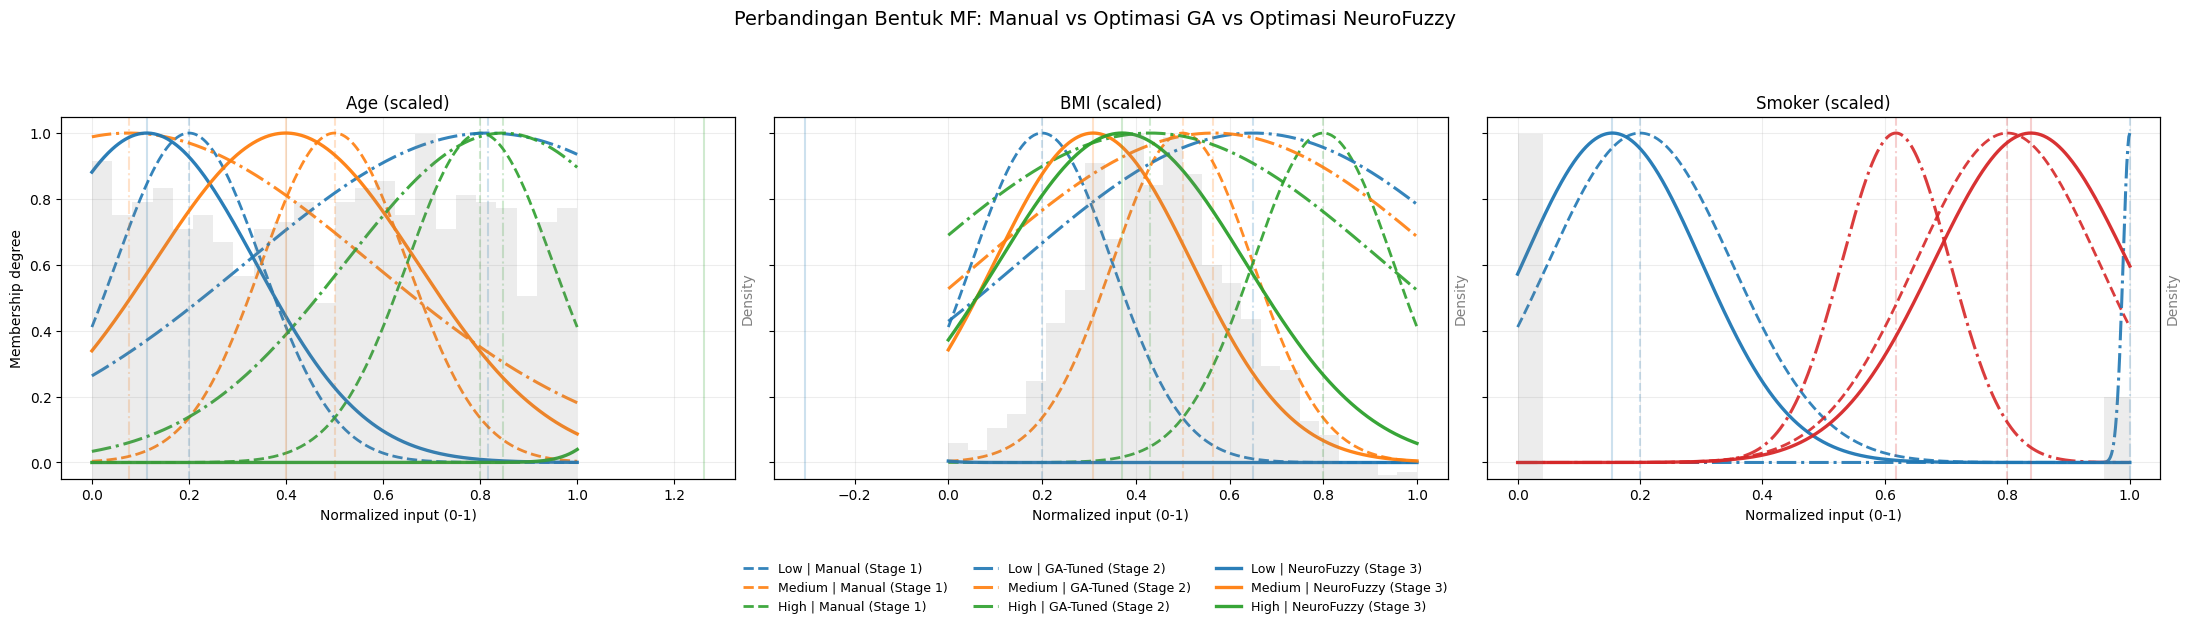


Ringkasan pergeseran center dan perubahan sigma:
Feature         MF  Center Manual  Center GA  Center ANN  Delta GA  Delta ANN            Arah GA           Arah ANN  Sigma Manual  Sigma GA  Sigma ANN
    age        Low         0.2000     0.8172      0.1130    0.6172    -0.0870 Geser ke kanan (+)  Geser ke kiri (-)        0.1500    0.5000     0.2248
    age     Medium         0.5000     0.0762      0.3995   -0.4238    -0.1005  Geser ke kiri (-)  Geser ke kiri (-)        0.1500    0.5000     0.2716
    age       High         0.8000     0.8474      1.2615    0.0474     0.4615 Geser ke kanan (+) Geser ke kanan (+)        0.1500    0.3255     0.1029
    bmi        Low         0.2000     0.6509     -0.3063    0.4509    -0.5063 Geser ke kanan (+)  Geser ke kiri (-)        0.1500    0.5000     0.0929
    bmi     Medium         0.5000     0.5657      0.3090    0.0657    -0.1910 Geser ke kanan (+)  Geser ke kiri (-)        0.1500    0.5000     0.2109
    bmi       High         0.8000     0.4308

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 13 — Analisis Pergeseran MF: Manual vs GA vs NeuroFuzzy
# ─────────────────────────────────────────────────────────────────────────────
print('=' * 75)
print('ANALISIS PERGESERAN KURVA MF (TAHAP 1 vs TAHAP 2 vs TAHAP 3)')
print('=' * 75)

def gaussian_curve(x, center, sigma):
    return np.exp(-0.5 * ((x - center) / (sigma + 1e-9)) ** 2)

manual_mf = {
    'age': {
        'centers': np.array(MF_CENTERS, dtype=float),
        'sigmas': np.array([MF_SIGMAS] * 3, dtype=float),
        'labels': ['Low', 'Medium', 'High'],
    },
    'bmi': {
        'centers': np.array(MF_CENTERS, dtype=float),
        'sigmas': np.array([MF_SIGMAS] * 3, dtype=float),
        'labels': ['Low', 'Medium', 'High'],
    },
    'smoker': {
        'centers': np.array([0.2, 0.8], dtype=float),
        'sigmas': np.array([MF_SIGMAS] * 2, dtype=float),
        'labels': ['Non-smoker', 'Smoker'],
    },
}

ga_mf = {
    'age': {
        'centers': ga_params['age_centers'].astype(float),
        'sigmas': ga_params['age_sigmas'].astype(float),
        'labels': ['Low', 'Medium', 'High'],
    },
    'bmi': {
        'centers': ga_params['bmi_centers'].astype(float),
        'sigmas': ga_params['bmi_sigmas'].astype(float),
        'labels': ['Low', 'Medium', 'High'],
    },
    'smoker': {
        'centers': ga_params['smoker_centers'].astype(float),
        'sigmas': ga_params['smoker_sigmas'].astype(float),
        'labels': ['Non-smoker', 'Smoker'],
    },
}

ann_params = model.get_mf_params()
ann_mf = {
    'age': {
        'centers': ann_params['age_centers'].astype(float),
        'sigmas': ann_params['age_sigmas'].astype(float),
        'labels': ['Low', 'Medium', 'High'],
    },
    'bmi': {
        'centers': ann_params['bmi_centers'].astype(float),
        'sigmas': ann_params['bmi_sigmas'].astype(float),
        'labels': ['Low', 'Medium', 'High'],
    },
    'smoker': {
        'centers': ann_params['smoker_centers'].astype(float),
        'sigmas': ann_params['smoker_sigmas'].astype(float),
        'labels': ['Non-smoker', 'Smoker'],
    },
}

feature_cfg = {
    'age': {'idx': 0, 'title': 'Age (scaled)', 'color_set': ['#1f77b4', '#ff7f0e', '#2ca02c']},
    'bmi': {'idx': 1, 'title': 'BMI (scaled)', 'color_set': ['#1f77b4', '#ff7f0e', '#2ca02c']},
    'smoker': {'idx': 2, 'title': 'Smoker (scaled)', 'color_set': ['#1f77b4', '#d62728']},
}

method_cfg = {
    'Manual (Stage 1)': {'ls': '--', 'lw': 2.0, 'alpha': 0.9},
    'GA-Tuned (Stage 2)': {'ls': '-.', 'lw': 2.2, 'alpha': 0.9},
    'NeuroFuzzy (Stage 3)': {'ls': '-', 'lw': 2.4, 'alpha': 0.95},
}

mf_by_method = {
    'Manual (Stage 1)': manual_mf,
    'GA-Tuned (Stage 2)': ga_mf,
    'NeuroFuzzy (Stage 3)': ann_mf,
}

x = np.linspace(0, 1, 600)
fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=True)

for ax, (feat, cfg) in zip(axes, feature_cfg.items()):
    # Overlay data density so shift reasons are easier to interpret.
    density_ax = ax.twinx()
    density_ax.hist(
        X_train[:, cfg['idx']], bins=24, density=True, color='gray', alpha=0.15,
        edgecolor='none'
    )
    density_ax.set_yticks([])
    density_ax.set_ylabel('Density', color='gray')

    labels = manual_mf[feat]['labels']
    colors = cfg['color_set']

    for method_name, mf_params in mf_by_method.items():
        style = method_cfg[method_name]
        centers = mf_params[feat]['centers']
        sigmas = mf_params[feat]['sigmas']

        for i, (c, s) in enumerate(zip(centers, sigmas)):
            curve = gaussian_curve(x, c, s)
            ax.plot(
                x, curve,
                linestyle=style['ls'], linewidth=style['lw'], alpha=style['alpha'],
                color=colors[i],
                label=f"{labels[i]} | {method_name}"
            )
            ax.axvline(c, linestyle=style['ls'], color=colors[i], alpha=0.22)

    ax.set_title(cfg['title'])
    ax.set_xlabel('Normalized input (0-1)')
    ax.grid(True, alpha=0.22)

axes[0].set_ylabel('Membership degree')
fig.suptitle('Perbandingan Bentuk MF: Manual vs Optimasi GA vs Optimasi NeuroFuzzy', y=1.02, fontsize=14)

# Use legend from first axis to avoid duplicate entries from all subplots.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=9, frameon=False)
plt.tight_layout(rect=[0, 0.14, 1, 0.96])
plt.show()

def shift_direction(delta, tol=1e-3):
    if delta > tol:
        return 'Geser ke kanan (+)'
    if delta < -tol:
        return 'Geser ke kiri (-)'
    return 'Stabil (~0)'

shift_rows = []
for feat in ['age', 'bmi', 'smoker']:
    labels = manual_mf[feat]['labels']
    for i, name in enumerate(labels):
        c_manual = manual_mf[feat]['centers'][i]
        c_ga = ga_mf[feat]['centers'][i]
        c_ann = ann_mf[feat]['centers'][i]
        s_manual = manual_mf[feat]['sigmas'][i]
        s_ga = ga_mf[feat]['sigmas'][i]
        s_ann = ann_mf[feat]['sigmas'][i]

        shift_rows.append({
            'Feature': feat,
            'MF': name,
            'Center Manual': c_manual,
            'Center GA': c_ga,
            'Center ANN': c_ann,
            'Delta GA': c_ga - c_manual,
            'Delta ANN': c_ann - c_manual,
            'Arah GA': shift_direction(c_ga - c_manual),
            'Arah ANN': shift_direction(c_ann - c_manual),
            'Sigma Manual': s_manual,
            'Sigma GA': s_ga,
            'Sigma ANN': s_ann,
        })

shift_df = pd.DataFrame(shift_rows)
print('\nRingkasan pergeseran center dan perubahan sigma:')
print(shift_df.round(4).to_string(index=False))

# Quick logic sanity checks for human interpretability.
def logic_checks(mf_params, title):
    checks = []
    for feat in ['age', 'bmi', 'smoker']:
        centers = mf_params[feat]['centers']
        sigmas = mf_params[feat]['sigmas']
        checks.append((f'{feat}: centers ascending', bool(np.all(np.diff(centers) > 0))))
        checks.append((f'{feat}: centers in [0,1]', bool(np.all((centers >= 0) & (centers <= 1)))))
        checks.append((f'{feat}: sigmas > 0', bool(np.all(sigmas > 0))))

    smoker_gap = mf_params['smoker']['centers'][1] - mf_params['smoker']['centers'][0]
    checks.append(('smoker: separation > 0.3', bool(smoker_gap > 0.3)))

    print(f'\nSanity check ({title}):')
    for item, ok in checks:
        mark = 'OK' if ok else 'Check again'
        print(f'  {mark:10s} | {item}')

logic_checks(ga_mf, 'GA-Tuned FIS')
logic_checks(ann_mf, 'NeuroFuzzy')

# Why curves shift: empirical signal summary from training data.
corr_age = np.corrcoef(X_train[:, 0], y_train)[0, 1]
corr_bmi = np.corrcoef(X_train[:, 1], y_train)[0, 1]
corr_smo = np.corrcoef(X_train[:, 2], y_train)[0, 1]

print('\nIndikasi alasan kurva bergeser (berdasarkan data train):')
print(f'  Corr(age, charges)    = {corr_age:+.3f}')
print(f'  Corr(bmi, charges)    = {corr_bmi:+.3f}')
print(f'  Corr(smoker, charges) = {corr_smo:+.3f}')
print('  Prinsip optimasi: GA/NeuroFuzzy menggeser center & sigma untuk menurunkan error prediksi.')
print('  Area input yang padat data atau punya dampak target lebih kuat biasanya mendapat penyesuaian lebih besar.')